In [2]:
# Carga de librerías y datos
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
data = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Limpieza
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data['Fare'] = np.log1p(data['Fare'])
data['familia_total'] = data['SibSp']+data['Parch']+1
data['viajasolo'] = (data['familia_total']==1).astype(int)
data = data.drop(columns=['SibSp','Parch','Name','Ticket','PassengerId','Cabin'])
data.columns

In [5]:
# Preparación de datos para el modelo
data = pd.get_dummies(data, columns=['Sex','Pclass', 'Embarked'], drop_first=True)
X = data.drop(columns=['Survived'])
y = data['Survived']
#Dividir el train y el test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test

In [7]:
# Entrenamiento del modelo
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

              precision    recall  f1-score   support

           0       0.81      0.87      0.83       105
           1       0.79      0.70      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



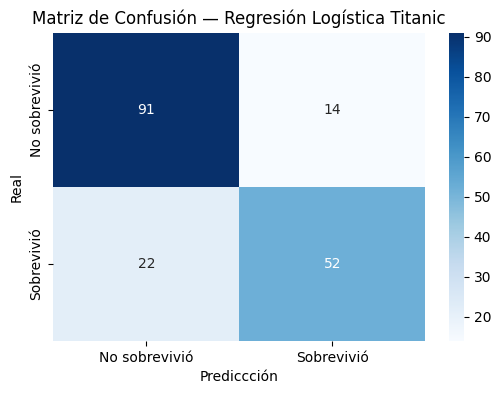

AUC-ROC: 0.8865


In [12]:
# Evaluación del Modelo
print(classification_report(y_test, y_pred))
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No sobrevivió','Sobrevivió'],
            yticklabels=['No sobrevivió','Sobrevivió'])
plt.title('Matriz de Confusión — Regresión Logística Titanic')
plt.ylabel('Real')
plt.xlabel('Prediccción')
plt.show()
y_proba = modelo.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.4f}")